In [ ]:
import numpy as np

In [ ]:
# Jumlah simulasi
N = 10000

# Distribusi elevasi tanggul
crest = np.random.normal(loc=5.0, scale=0.2, size=N)

# Distribusi muka air banjir
water = np.random.normal(loc=4.2, scale=0.5, size=N)

# Fungsi kegagalan
g = crest - water

In [ ]:
# Probabilitas kegagalan
Pf = np.sum(g < 0) / N

# Keandalan
R = 1 - Pf

print(Pf)
print(R)

0.0649
0.9351


In [ ]:
status = np.where(g >= 0, "aman", "overtopping")

print("Crest\tWater\tg\tStatus")
for i in range(10):
    print(f"{crest[i]:.2f}\t{water[i]:.2f}\t{g[i]:.2f}\t{status[i]}")

Crest	Water	g	Status
4.72	4.49	0.23	aman
5.11	5.21	-0.10	overtopping
4.98	4.45	0.52	aman
4.94	3.47	1.47	aman
5.15	3.80	1.35	aman
4.91	3.87	1.05	aman
5.09	4.13	0.97	aman
4.90	4.54	0.36	aman
5.05	4.35	0.70	aman
4.84	4.61	0.23	aman


In [ ]:
jumlah_gagal = np.sum(g < 0)

print(f"Jumlah kegagalan = {jumlah_gagal}")
print(f"Probabilitas kegagalan = {Pf:.4f}")
print(f"Keandalan = {R:.4f}")

Jumlah kegagalan = 716
Probabilitas kegagalan = 0.0716
Keandalan = 0.9284


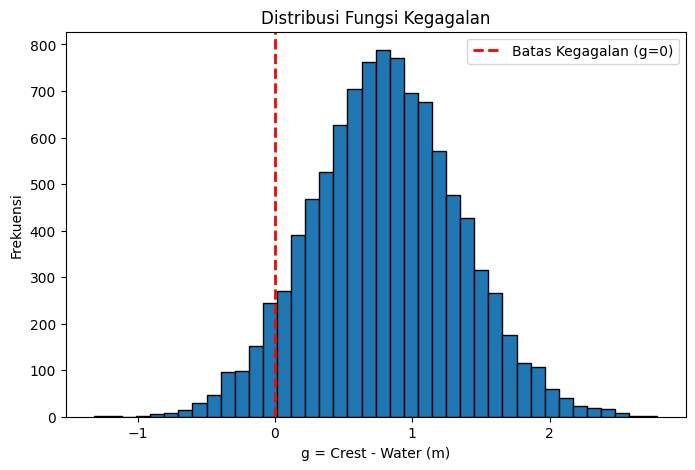

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(g, bins=40, edgecolor='black')
plt.axvline(0, color='red', linestyle='--', linewidth=2, label='Batas Kegagalan (g=0)')
plt.xlabel('g = Crest - Water (m)')
plt.ylabel('Frekuensi')
plt.title('Distribusi Fungsi Kegagalan')
plt.legend()
plt.show()

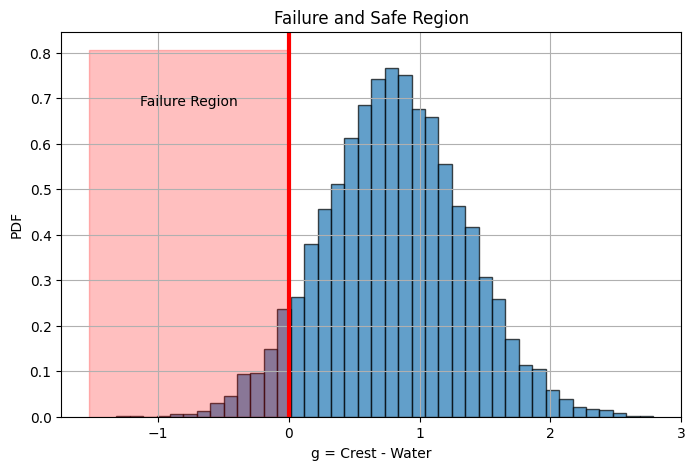

In [ ]:
# -------------------------------
# Histogram (PDF)
# -------------------------------
plt.figure(figsize=(8,5))

# Histogram dengan normalisasi PDF
plt.hist(g,
         bins=40,
         density=True,
         edgecolor='black',
         alpha=0.7)

# Garis batas kegagalan
plt.axvline(x=0,
            color='red',
            linewidth=3)

# Mendapatkan batas sumbu
ymax = plt.ylim()[1]
xmin = plt.xlim()[0]

# Arsiran daerah gagal
plt.fill_between([xmin,0],
                 [0,0],
                 [ymax,ymax],
                 color='red',
                 alpha=0.25)

# Tulisan
plt.text((xmin+0)/2,
         ymax*0.85,
         "Failure Region",
         ha='center',
         color='black')

plt.xlabel("g = Crest - Water")
plt.ylabel("PDF")
plt.title("Failure and Safe Region")
plt.grid(True)

plt.show()


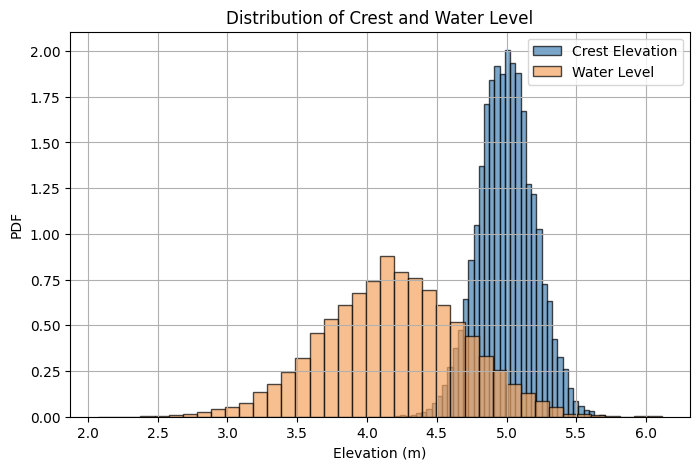

In [ ]:
# Plot Histogram PDF
# ==========================
plt.figure(figsize=(8,5))

# Histogram Crest
plt.hist(crest,
         bins=40,
         density=True,
         alpha=0.7,
         color='steelblue',
         edgecolor='black',
         label='Crest Elevation')

# Histogram Water
plt.hist(water,
         bins=40,
         density=True,
         alpha=0.7,
         color='sandybrown',
         edgecolor='black',
         label='Water Level')

plt.xlabel('Elevation (m)')
plt.ylabel('PDF')
plt.title('Distribution of Crest and Water Level')
plt.legend()
plt.grid(True)

plt.show()

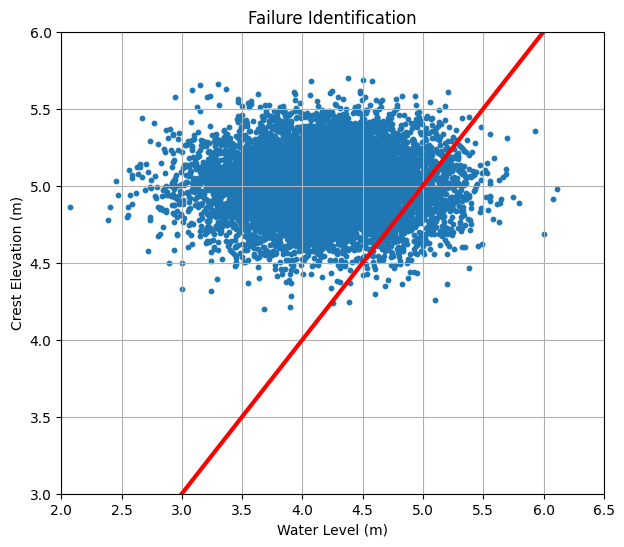

In [ ]:
# ==================================
# Scatter Plot
# ==================================
plt.figure(figsize=(7,6))

plt.scatter(water,
            crest,
            s=10,
            color='tab:blue')

# Garis Water = Crest (y = x)
x = np.linspace(3, 6, 100)
plt.plot(x, x, 'r', linewidth=3)

plt.xlabel('Water Level (m)')
plt.ylabel('Crest Elevation (m)')
plt.title('Failure Identification')

plt.xlim(2,6.5)
plt.ylim(3,6)

plt.grid(True)

plt.show()

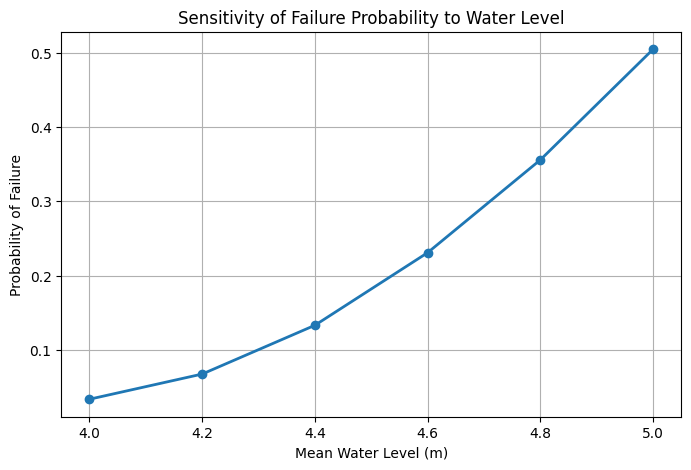

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =====================================
# Parameter
# =====================================
np.random.seed(42)

N = 10000

crest_mean = 5.0
crest_std = 0.2

water_mean = np.arange(4.0, 5.01, 0.2)   # 4.0, 4.2, ..., 5.0
water_std = 0.5

Pf = []

# =====================================
# Monte Carlo untuk setiap mean water
# =====================================
for wm in water_mean:

    crest = np.random.normal(crest_mean, crest_std, N)
    water = np.random.normal(wm, water_std, N)

    g = crest - water

    Pf.append(np.mean(g < 0))

Pf = np.array(Pf)

# =====================================
# Plot
# =====================================
plt.figure(figsize=(8,5))

plt.plot(water_mean,
         Pf,
         marker='o',
         linewidth=2)

plt.xlabel("Mean Water Level (m)")
plt.ylabel("Probability of Failure")
plt.title("Sensitivity of Failure Probability to Water Level")

plt.grid(True)

plt.show()

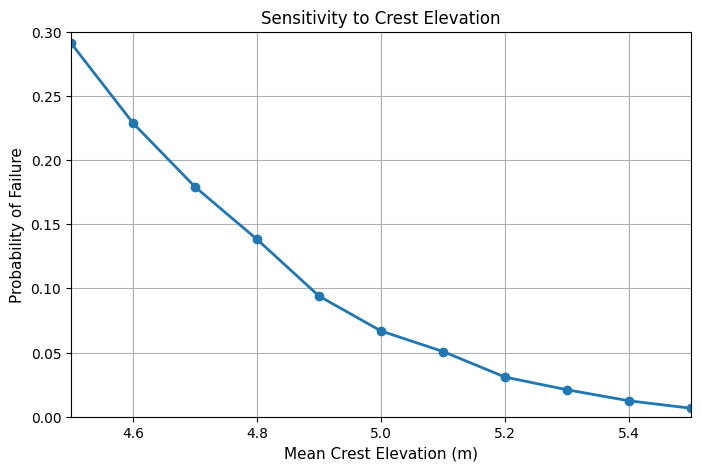

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =====================================
# Parameter Simulasi
# =====================================
np.random.seed(42)

N = 10000

# Parameter tanggul
crest_mean = np.arange(4.5, 5.51, 0.1)
crest_std = 0.2

# Parameter muka air
water_mean = 4.2
water_std = 0.5

# Menyimpan probabilitas kegagalan
Pf = np.zeros(len(crest_mean))

# =====================================
# Monte Carlo Simulation
# =====================================
for i in range(len(crest_mean)):

    crest = np.random.normal(crest_mean[i], crest_std, N)
    water = np.random.normal(water_mean, water_std, N)

    # Fungsi kegagalan
    g = crest - water

    # Probabilitas kegagalan
    Pf[i] = np.sum(g < 0) / N

# =====================================
# Grafik
# =====================================
plt.figure(figsize=(8,5))

plt.plot(
    crest_mean,
    Pf,
    linewidth=2,
    marker='o',
    markersize=6
)

plt.xlabel('Mean Crest Elevation (m)', fontsize=11)
plt.ylabel('Probability of Failure', fontsize=11)
plt.title('Sensitivity to Crest Elevation', fontsize=12)

plt.xlim(4.5,5.5)
plt.ylim(0,0.30)

plt.grid(True)

plt.show()

In [ ]:
#1. Apakah menaikan tanggul 20cm efektif?
##  Ya, setiap kenaikan tanggul setinggi 20cm
##  dapat mengurangi probabilitas kegagalan
##  mencapai +-5%

In [ ]:
#2. Apakah pengurangan muka air banjir lebih efektif?
##  Ya, pengurangan muka air banjir 20cm menghasilkan
##  dampak pengurangan probabilitas
##  kegagalan sebesar +-10%

In [ ]:
#3. Variabel mana yang paling sensitif?
##  Pengurangan muka air banjir